In [1]:
import pandas as pd
from sqlalchemy import create_engine, URL
from getpass import getpass

password = getpass("PostgreSQL Passwort: ")

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="olist"
)

engine = create_engine(url)

df = pd.read_sql("SELECT * FROM mart.ml_model_dataset", engine)
df.head()

PostgreSQL Passwort:  ········


,seller_id,origin,business_segment,lead_type,lead_behaviour_profile,time_to_close_days,revenue,high_value_seller
0,2c43fb513632d29b3b58df74816f1b06,organic_search,pet,online_medium,cat,5,858.00,0
1,612170e34b97004b3ba37eae81836b4c,organic_search,home_appliances,online_big,cat,63,23065.02,1
2,ed8cb7b190ceb6067227478e48cf8dde,unknown,home_appliances,industry,wolf,267,573.50,0
3,1c742ac33582852aaf3bcfbf5893abcf,organic_search,health_beauty,online_medium,missing,1,97.90,0
4,44ed138eca6214d572ce1d813fb0049b,unknown,health_beauty,offline,cat,4,129.79,0


### Dataset Overview

We first inspect the structure of the dataset and basic summary statistics to understand the distribution of the variables and identify potential data quality issues.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               380 non-null    object 
 1   origin                  380 non-null    object 
 2   business_segment        380 non-null    object 
 3   lead_type               380 non-null    object 
 4   lead_behaviour_profile  380 non-null    object 
 5   time_to_close_days      380 non-null    int64  
 6   revenue                 380 non-null    float64
 7   high_value_seller       380 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 23.9+ KB


In [3]:
df.describe()

,time_to_close_days,revenue,high_value_seller
count,380.000000,380.000000,380.000000
mean,28.055263,1781.188105,0.200000
std,50.806941,6800.937058,0.400527
min,-2.000000,18.900000,0.000000
25%,4.000000,179.650000,0.000000
50%,10.000000,547.405000,0.000000
75%,25.250000,1286.000000,0.000000
max,369.000000,113628.970000,1.000000


The revenue distribution is highly skewed. Most sellers generate relatively small revenue, while a few sellers generate very large amounts.

This pattern is typical for marketplace platforms and reflects a long-tail distribution where a small fraction of sellers accounts for a large share of revenue.

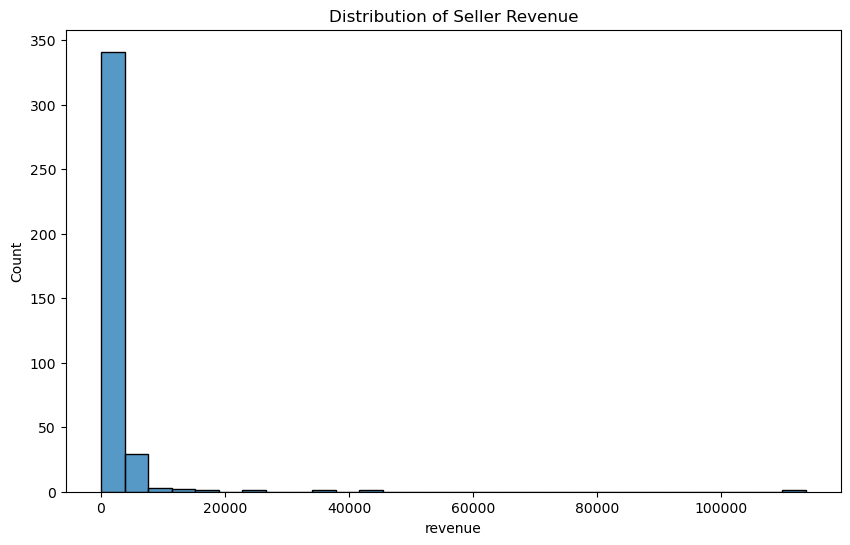

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df["revenue"], bins=30)

plt.title("Distribution of Seller Revenue")
plt.show()

The revenue distribution is highly skewed. Most sellers generate relatively small revenue, while a few sellers generate very large amounts.

This pattern is typical for marketplace platforms and reflects a long-tail distribution where a small fraction of sellers accounts for a large share of revenue.

### Feature Encoding

Categorical variables are transformed using one-hot encoding so they can be used as input features for machine learning models.


In [5]:
import pandas as pd
categorical_cols = [
    "origin",
    "business_segment",
    "lead_type",
    "lead_behaviour_profile"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols)

df_encoded.head()

,seller_id,time_to_close_days,revenue,high_value_seller,origin_direct_traffic,origin_display,origin_email,origin_missing,origin_organic_search,origin_other,...,lead_type_online_medium,lead_type_online_small,lead_type_online_top,lead_behaviour_profile_cat,"lead_behaviour_profile_cat, wolf",lead_behaviour_profile_eagle,"lead_behaviour_profile_eagle, cat",lead_behaviour_profile_missing,lead_behaviour_profile_shark,lead_behaviour_profile_wolf
0,2c43fb513632d29b3b58df74816f1b06,5,858.00,0,False,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
1,612170e34b97004b3ba37eae81836b4c,63,23065.02,1,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,ed8cb7b190ceb6067227478e48cf8dde,267,573.50,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1c742ac33582852aaf3bcfbf5893abcf,1,97.90,0,False,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,44ed138eca6214d572ce1d813fb0049b,4,129.79,0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [6]:
df_encoded.shape

(380, 58)

In [9]:
df_encoded["time_to_close_days"] = df_encoded["time_to_close_days"].clip(lower=0)

In [10]:
df_encoded["time_to_close_days"].describe()

count    380.000000
mean      28.060526
std       50.803923
min        0.000000
25%        4.000000
50%       10.000000
75%       25.250000
max      369.000000
Name: time_to_close_days, dtype: float64

### Train-Test Split

The dataset is split into training and test sets (80/20). Stratified sampling is used to preserve the original class distribution of high-value sellers.

In [13]:
X = df_encoded.drop(columns=["seller_id", "revenue", "high_value_seller"])
y = df_encoded["high_value_seller"]

In [14]:
X.shape

(380, 55)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(304, 55)
(76, 55)


### Baseline Model

A Random Forest classifier is trained as a baseline model to predict whether a seller becomes a high-value seller.

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [19]:
y_pred = model.predict(X_test)


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.90        61
           1       0.67      0.13      0.22        15

    accuracy                           0.82        76
   macro avg       0.74      0.56      0.56        76
weighted avg       0.79      0.82      0.76        76



The model achieves an accuracy of around 82%. However, the recall for high-value sellers is low, meaning the model fails to correctly identify many sellers who actually become high-value.

This is likely due to class imbalance, as high-value sellers represent only a small portion of the dataset.

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8157894736842105


### Feature Importance

Feature importance scores are analyzed to identify which variables contribute most to predicting high-value sellers.

In [22]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

time_to_close_days                                  0.219290
lead_type_online_big                                0.050622
origin_paid_search                                  0.036577
origin_organic_search                               0.036221
lead_behaviour_profile_cat                          0.033539
origin_unknown                                      0.030133
lead_behaviour_profile_eagle                        0.028998
lead_behaviour_profile_missing                      0.028770
business_segment_construction_tools_house_garden    0.027868
lead_type_online_medium                             0.025860
dtype: float64

The most important feature is `time_to_close_days`, suggesting that faster lead conversion is associated with higher seller performance.

Marketing-related features such as lead type and acquisition channel also play a role in predicting high-value sellers.

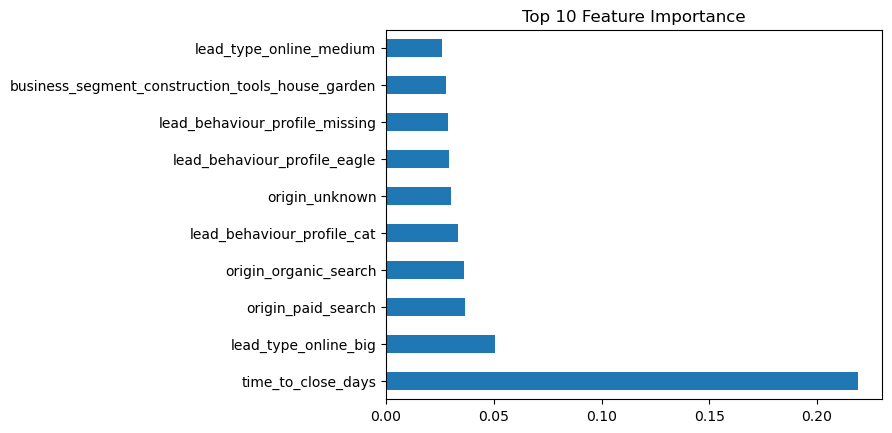

In [23]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="barh")

plt.title("Top 10 Feature Importance")
plt.show()

In [24]:
feature_importance.head(10)

time_to_close_days                                  0.219290
lead_type_online_big                                0.050622
origin_paid_search                                  0.036577
origin_organic_search                               0.036221
lead_behaviour_profile_cat                          0.033539
origin_unknown                                      0.030133
lead_behaviour_profile_eagle                        0.028998
lead_behaviour_profile_missing                      0.028770
business_segment_construction_tools_house_garden    0.027868
lead_type_online_medium                             0.025860
dtype: float64

The feature importance analysis shows that conversion speed (`time_to_close_days`) is the most influential factor in predicting high-value sellers.

Marketing-related variables such as lead type and acquisition channels also contribute to the prediction.

However, the overall model performance suggests that the available features provide limited predictive power. Additional data or richer seller features would likely improve the model's ability to identify high-value sellers.

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.90        61
           1       0.67      0.13      0.22        15

    accuracy                           0.82        76
   macro avg       0.74      0.56      0.56        76
weighted avg       0.79      0.82      0.76        76



Applying class weighting does not significantly change the model performance.

The recall for high-value sellers remains low, suggesting that the available features provide limited predictive signal for distinguishing high-value sellers from normal sellers.

This indicates that additional features or alternative modeling approaches may be required to improve performance.

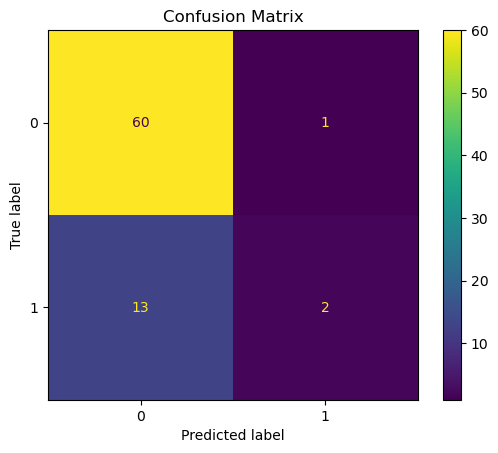

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


### Confusion Matrix

The confusion matrix shows that the model correctly classifies most normal sellers but struggles to identify high-value sellers.

A large portion of high-value sellers are misclassified as normal sellers, which explains the low recall for the positive class.

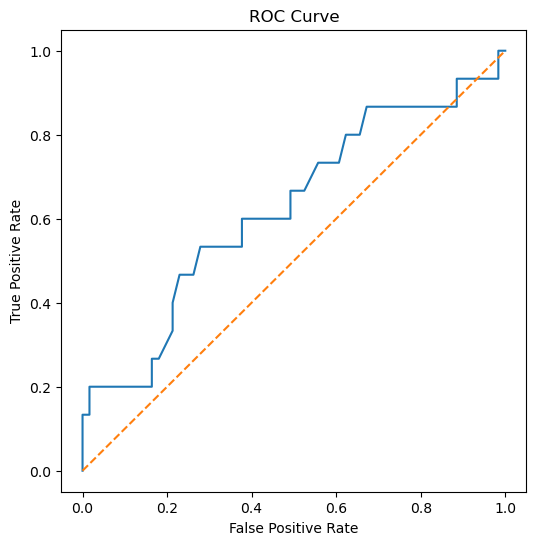

AUC: 0.6240437158469945


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

### ROC Curve

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate.

The AUC score summarizes the model's ability to distinguish between high-value and normal sellers.

Values closer to 1 indicate better predictive performance, while values around 0.5 suggest little predictive power.

## Business Insights

The analysis provides several insights into factors associated with high-value sellers.

**Conversion Speed**
The most important feature in the model is `time_to_close_days`. Sellers who convert faster after the first contact are more likely to become high-value sellers. This suggests that lead readiness and initial engagement quality are strong indicators of future performance.

**Lead Quality**
Certain lead types, such as larger online leads, show higher importance in the model. This indicates that some lead categories are more likely to produce high-performing sellers.

**Marketing Channels**
Acquisition channels such as paid search and organic search also contribute to predicting seller success. This suggests that marketing channel quality can influence the long-term value of acquired sellers.

**Model Limitations**
The predictive performance of the model remains modest, with an AUC score of around 0.62. This indicates that additional features, such as seller activity, product portfolio, or customer reviews, would likely improve the model’s ability to identify high-value sellers.